In [1]:
import numpy as np
from utils.data_utils import TitanicDataHelper
import warnings
import math
from utils.evaluation_utils import EvaluationHelper
warnings.filterwarnings("ignore")

## Data Visualization

In [2]:
x_train, x_test, y_train, y_test = TitanicDataHelper.load_dataset()
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((712, 10), (179, 10), (712,), (179,))

In [3]:
x_train.head()

,Pclass,Age,SibSp,Parch,Fare,UncommonTitle,YoungTitle,Sex_male,Embarked_Q,Embarked_S
709,0.824654,-0.091831,0.445182,0.705697,-0.339157,-0.174207,1.737341,0.741906,-0.308627,-1.593335
439,-0.376069,0.132682,-0.481630,-0.493483,-0.429806,-0.174207,-0.574784,0.741906,-0.308627,0.626733
840,0.824654,-0.690532,-0.481630,-0.493483,-0.478991,-0.174207,-0.574784,0.741906,-0.308627,0.626733
720,-0.376069,-1.738261,-0.481630,0.705697,-0.000034,-0.174207,1.737341,-1.345987,-0.308627,0.626733
39,0.824654,-1.139559,0.445182,-0.493483,-0.415639,-0.174207,1.737341,-1.345987,-0.308627,-1.593335


In [4]:
y_train.head()

709    1
439    0
840    0
720    1
39     1
Name: Survived, dtype: int64

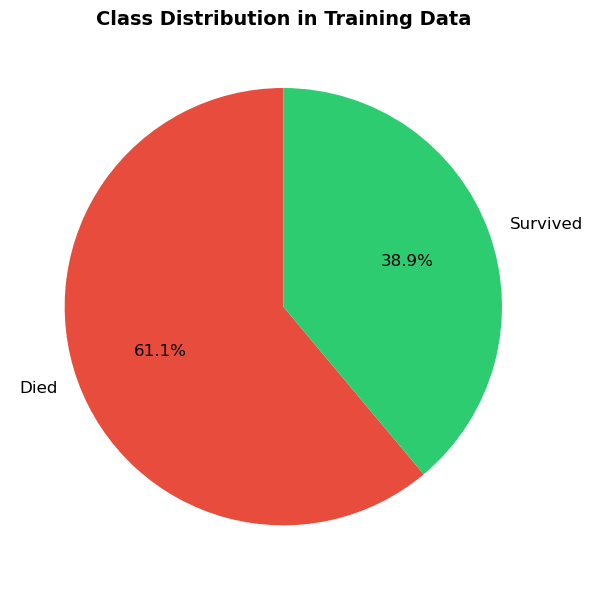

Died: 435 (61.1%)
Survived: 277 (38.9%)


In [5]:
TitanicDataHelper.plot_outcome_distribution(x_train, y_train)

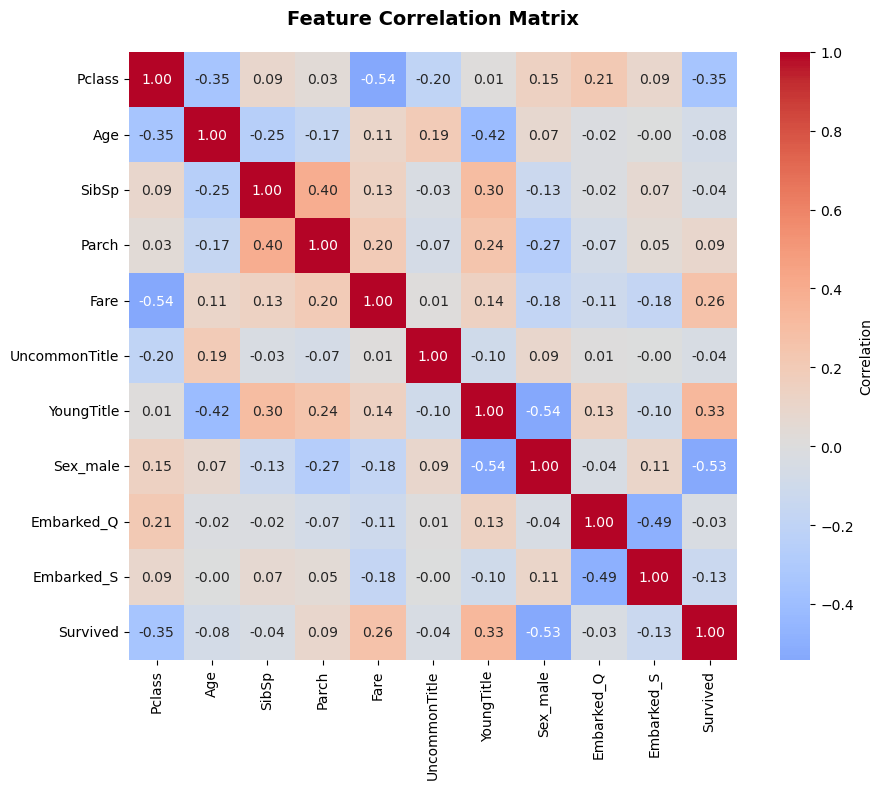

In [6]:
TitanicDataHelper.plot_correlation(x_train, y_train)

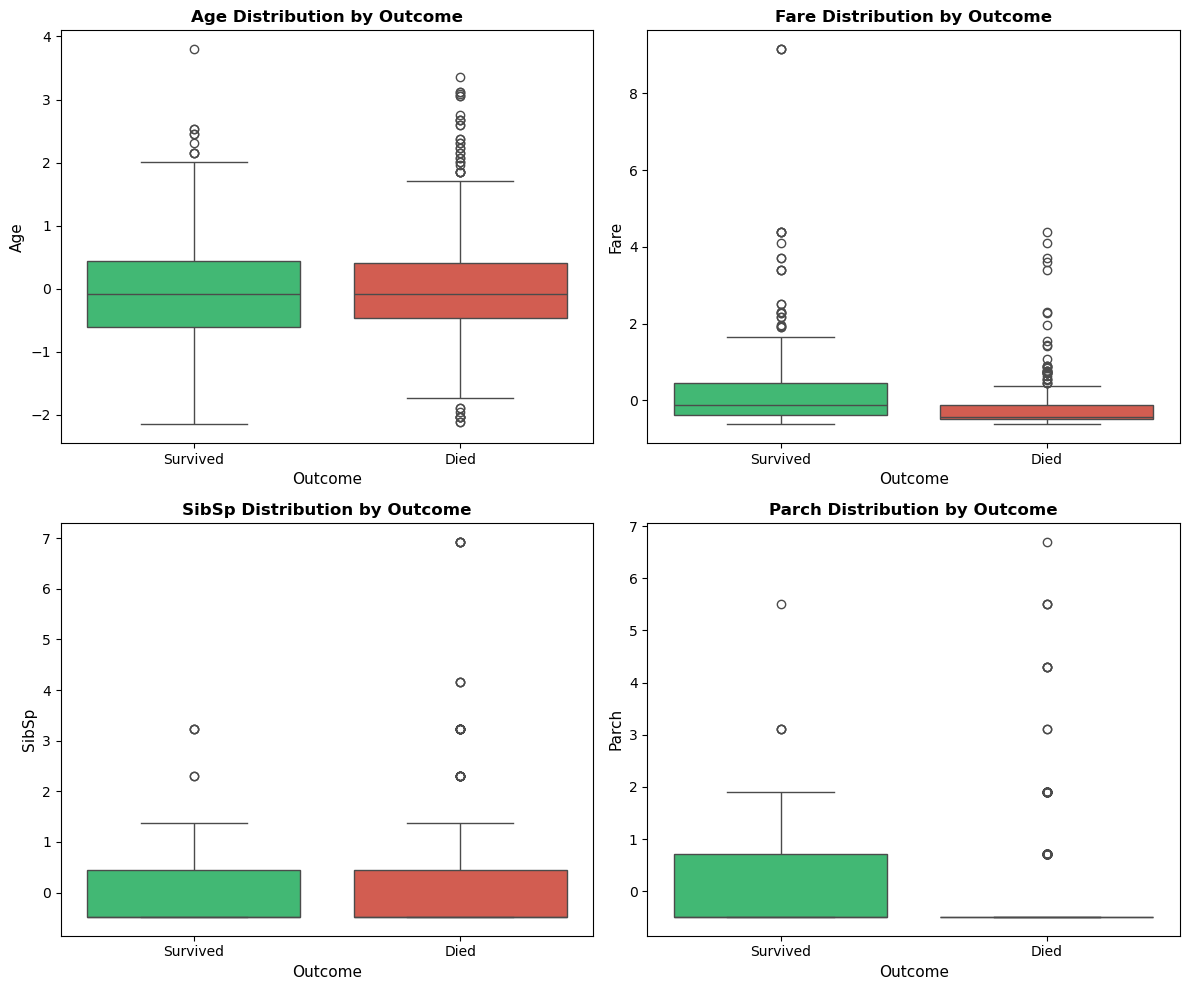

In [7]:
TitanicDataHelper.plot_boxplots(x_train, y_train)

## Model Building

In [8]:
x_train = np.array(x_train)
x_test = np.array(x_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [9]:
def predict(x, k=5):
    distances = []
    
    for i in range (len(x_train)):
        distances.append({"idx": i, "dist": math.dist(x, x_train[i])})
    
    distances = sorted(distances, key=lambda d: d["dist"])
    neighbors = distances[:k]
    
    neighbor_indices = [neighbor["idx"] for neighbor in neighbors]
    neighbor_labels = y_train[neighbor_indices]
    
    values, counts = np.unique(neighbor_labels, return_counts=True)
    
    return values[np.argmax(counts)]

## Model Evaluation

In [10]:
predictions = []

for x in x_test:
    prediction = predict(x, 4)
    predictions.append(prediction)

predictions = np.array(predictions)

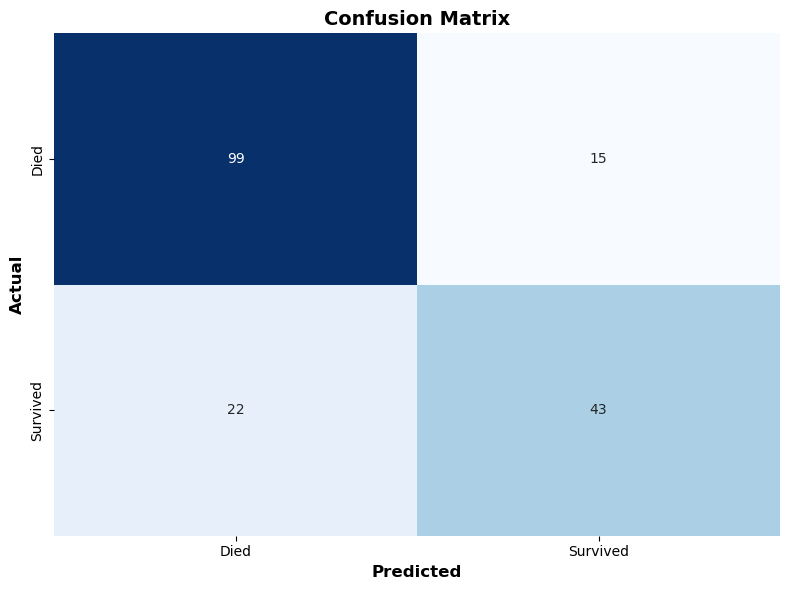

True Negatives: 99
False Positives: 15
False Negatives: 22
True Positives: 43

Sensitivity (Recall): 0.6615
Specificity: 0.8684
Precision: 0.7414
Accuracy: 0.7933
F1 Score: 0.6992


In [11]:
EvaluationHelper.plot_confusion_matrix(y_test, predictions, class_names=["Died", "Survived"])

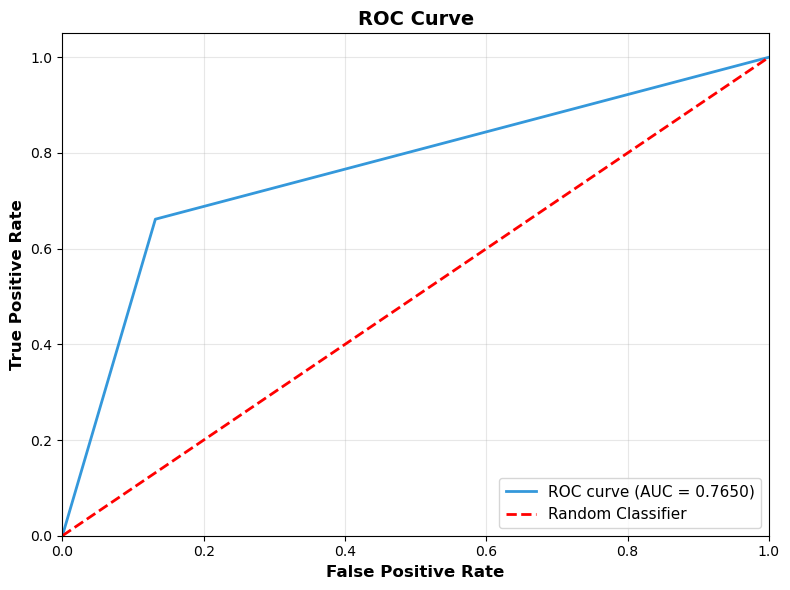

Area Under the Curve (AUC): 0.7650


In [12]:
EvaluationHelper.plot_roc_curve(y_test, predictions)